<a href="https://colab.research.google.com/github/17Juan08/Energy-Anomaly-Detection/blob/main/Energy_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción y Planteamiento del Problema

A nivel mundial, los edificios y la infraestructura urbana representan aproximadamente un tercio del consumo total de energía. Diversos estudios estiman que más del **20 % de esta energía se desperdicia** debido a fallas mecánicas en los equipos, deterioro de la infraestructura, configuraciones operativas inadecuadas o errores humanos. Esta ineficiencia no solo incrementa los costos operativos, sino que también contribuye significativamente al aumento de las emisiones de carbono.

Con la adopción de tecnologías como el **Internet de las Cosas (IoT)** y las **Redes Eléctricas Inteligentes (Smart Grids)**, los edificios modernos generan enormes volúmenes de información mediante medidores inteligentes (*Smart Meters*). Estos dispositivos registran continuamente el consumo energético, produciendo millones de observaciones en forma de series temporales.

El análisis de estos datos mediante técnicas de **Machine Learning** permite identificar automáticamente patrones de consumo anómalos que pueden estar asociados con fallas en equipos, errores de medición, fugas de energía o comportamientos inusuales.

En este proyecto se desarrolla un modelo predictivo para detectar **anomalías puntuales (*point anomalies*)** en el consumo horario de energía eléctrica utilizando información proveniente de aproximadamente **400 edificios comerciales** durante un año completo. El conjunto de datos corresponde a una versión extendida y etiquetada del reconocido dataset de la competencia **ASHRAE – Great Energy Predictor III**, ampliamente utilizado en investigaciones sobre eficiencia energética.

---

# 2. Objetivos del Proyecto

## 🎯 Objetivo General

Desarrollar un **pipeline de Machine Learning** para detectar automáticamente anomalías en el consumo horario de energía eléctrica mediante un modelo de **clasificación binaria**, permitiendo identificar comportamientos atípicos de manera precisa y eficiente.

## Objetivos Específicos

- Diseñar un proceso de preprocesamiento adecuado para datos de series temporales, incluyendo la generación de variables temporales y características derivadas.

- Implementar estrategias de ingeniería de características, como variables de rezago (*lag features*) y diferenciación temporal, con el fin de capturar la dinámica del consumo energético.

- Aplicar técnicas para mitigar el desbalance de clases y mejorar la capacidad del modelo para detectar eventos anómalos.

- Entrenar y evaluar modelos de Machine Learning para la clasificación de anomalías en grandes volúmenes de datos.

- Analizar el desempeño del modelo y su utilidad como herramienta de apoyo para el mantenimiento predictivo y la gestión eficiente de la energía.

### Objetivo de Negocio

Desarrollar un sistema de alerta temprana que permita a los administradores de edificios detectar rápidamente consumos anómalos o fallas en los medidores inteligentes, reduciendo costos operativos y facilitando el mantenimiento preventivo.

### Objetivo de Ingeniería de Datos

Implementar un pipeline eficiente de procesamiento de datos capaz de manejar grandes volúmenes de información mediante técnicas avanzadas de preprocesamiento para series temporales y estrategias de optimización del entrenamiento.

---

# 3. Métrica de Evaluación

El conjunto de datos presenta un **fuerte desbalance de clases**, ya que las observaciones normales representan la gran mayoría de los registros, mientras que las anomalías corresponden únicamente a un pequeño porcentaje.

Por esta razón, la **precisión global (Accuracy)** no constituye una métrica adecuada, pues un modelo podría obtener una alta precisión simplemente clasificando todos los registros como normales.

En su lugar, el desempeño del modelo se evalúa mediante la **Curva ROC (Receiver Operating Characteristic)** y el **Área Bajo la Curva (AUC-ROC)**.

El **AUC-ROC** mide la capacidad del modelo para distinguir entre observaciones normales y anómalas, independientemente del umbral de decisión. Un valor cercano a **1.0** indica una excelente capacidad de discriminación, mientras que un valor cercano a **0.5** equivale a un clasificador aleatorio.

Esta métrica es especialmente apropiada para problemas de detección de anomalías, ya que busca:

- Maximizar la detección de anomalías reales (*True Positive Rate*).
- Minimizar la generación de falsas alarmas (*False Positive Rate*).
- Evaluar el rendimiento del modelo de forma independiente del umbral de clasificación.



# Librerias


In [ ]:
import os
import kagglehub
from google.colab import userdata

import duckdb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm, trange
import datetime

import warnings
warnings.filterwarnings('ignore')

from sklearn import metrics
from sklearn.preprocessing import StandardScaler


import lightgbm as lgb


# 1. Descarga del dataset

In [ ]:
# Configurar la variable de entorno directamente en Colab con tu token
os.environ['xxxxxxxxxxx'] = 'xxxxxxxxxxxxxxxxxxx'

path = kagglehub.competition_download('energy-anomaly-detection')

print("Path to competition files:", path)

100%|██████████| 204M/204M [00:02<00:00, 77.8MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/energy-anomaly-detection


In [ ]:
# Definimos la ruta donde kagglehub guardó los archivos
path = "/root/.cache/kagglehub/competitions/energy-anomaly-detection"

# Listar los archivos dentro de esa carpeta
print("Archivos listos para el proyecto:")
for archivo in os.listdir(path):
    print(f"- {archivo}")

Archivos listos para el proyecto:
- sample_submission.csv
- train_features.csv
- test.csv
- train.csv
- test_features.csv


In [ ]:
# Ruta al archivo de entrenamiento
archivo_train_features = os.path.join(path, "train_features.csv")

# Carga  de dataset indicando que la columna de fecha es una estampa de tiempo
df_features = pd.read_csv(archivo_train_features)


# 2. Exploratory Data Analysis

In [ ]:
df_features.head()

,building_id,timestamp,meter_reading,anomaly,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,gte_meter,gte_meter_hour,gte_meter_weekday,gte_meter_month,gte_meter_building_id,gte_meter_primary_use,gte_meter_site_id,gte_meter_building_id_hour,gte_meter_building_id_weekday,gte_meter_building_id_month
0,1,2016-01-01 00:00:00,NaN,0,0,Education,2720,104,0,19.4,...,4.116,3.981,4.146,4.12,3.569,4.489,4.079,3.554,3.538,3.845
1,32,2016-01-01 00:00:00,NaN,0,0,Office,48392,105,0,19.4,...,4.116,3.981,4.146,4.12,4.513,4.211,4.079,4.128,4.579,4.317
2,41,2016-01-01 00:00:00,NaN,0,0,Office,93860,68,0,19.4,...,4.116,3.981,4.146,4.12,4.108,4.211,4.079,4.103,4.140,4.114
3,55,2016-01-01 00:00:00,NaN,0,0,Office,16726,111,0,19.4,...,4.116,3.981,4.146,4.12,3.506,4.211,4.079,3.308,3.565,3.813
4,69,2016-01-01 00:00:00,NaN,0,0,Parking,387638,100,0,19.4,...,4.116,3.981,4.146,4.12,3.035,3.623,4.079,3.892,3.090,3.577


In [ ]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1749494 entries, 0 to 1749493
Data columns (total 57 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   building_id                    int64  
 1   timestamp                      object 
 2   meter_reading                  float64
 3   anomaly                        int64  
 4   site_id                        int64  
 5   primary_use                    object 
 6   square_feet                    int64  
 7   year_built                     int64  
 8   floor_count                    int64  
 9   air_temperature                float64
 10  cloud_coverage                 int64  
 11  dew_temperature                float64
 12  precip_depth_1_hr              int64  
 13  sea_level_pressure             float64
 14  wind_direction                 int64  
 15  wind_speed                     float64
 16  air_temperature_mean_lag7      float64
 17  air_temperature_max_lag7       float64
 18  ai

In [ ]:
df_features.isna().sum()

,0
building_id,0
timestamp,0
meter_reading,107653
anomaly,0
site_id,0
primary_use,0
square_feet,0
year_built,0
floor_count,0
air_temperature,0


In [ ]:
# valores duplicados
print('Observaciones duplicados en el dataset: ', df_features.duplicated().sum())

Observaciones duplicados en el dataset:  0


In [ ]:
df_features[df_features['meter_reading'] == 1
            ]['anomaly'].value_counts()

,count
anomaly,
1,17053
0,6


El dataset cuenta con 0 valores duplicados, lo que garantiza la integridad de los registros secuenciales. Sin embargo, se identificó que la columna timestamp está parseada actualmente como tipo object (texto). Esta variable será transformada al tipo de dato adecuado (datetime64) en la siguiente fase de preparación de datos para facilitar la extracción de componentes temporales. e detectaron 107,653 valores nulos concentrados exclusivamente en la variable objetivo meter_reading.

In [ ]:
ints = []
floats = []
objects = []

for col in df_features.columns:
    if df_features[col].dtype == 'int64':
        ints.append(col)
    elif df_features[col].dtype == 'float64':
        floats.append(col)
    else:
        objects.append(col)

## 2.1 Analisis de datatype de columnas
### Datatype **int**

In [ ]:
ints

['building_id',
 'anomaly',
 'site_id',
 'square_feet',
 'year_built',
 'floor_count',
 'cloud_coverage',
 'precip_depth_1_hr',
 'wind_direction',
 'hour',
 'weekday',
 'month',
 'year',
 'is_holiday']

Las columnas desde **"hour"** hasta **"is_holiday"** no son más que la forma expandida de la marca de tiempo, por lo que podemos eliminar esa característica.

In [ ]:
df_features[ints].nunique()

,0
building_id,200
anomaly,2
site_id,14
square_feet,200
year_built,32
floor_count,12
cloud_coverage,11
precip_depth_1_hr,128
wind_direction,44
hour,24


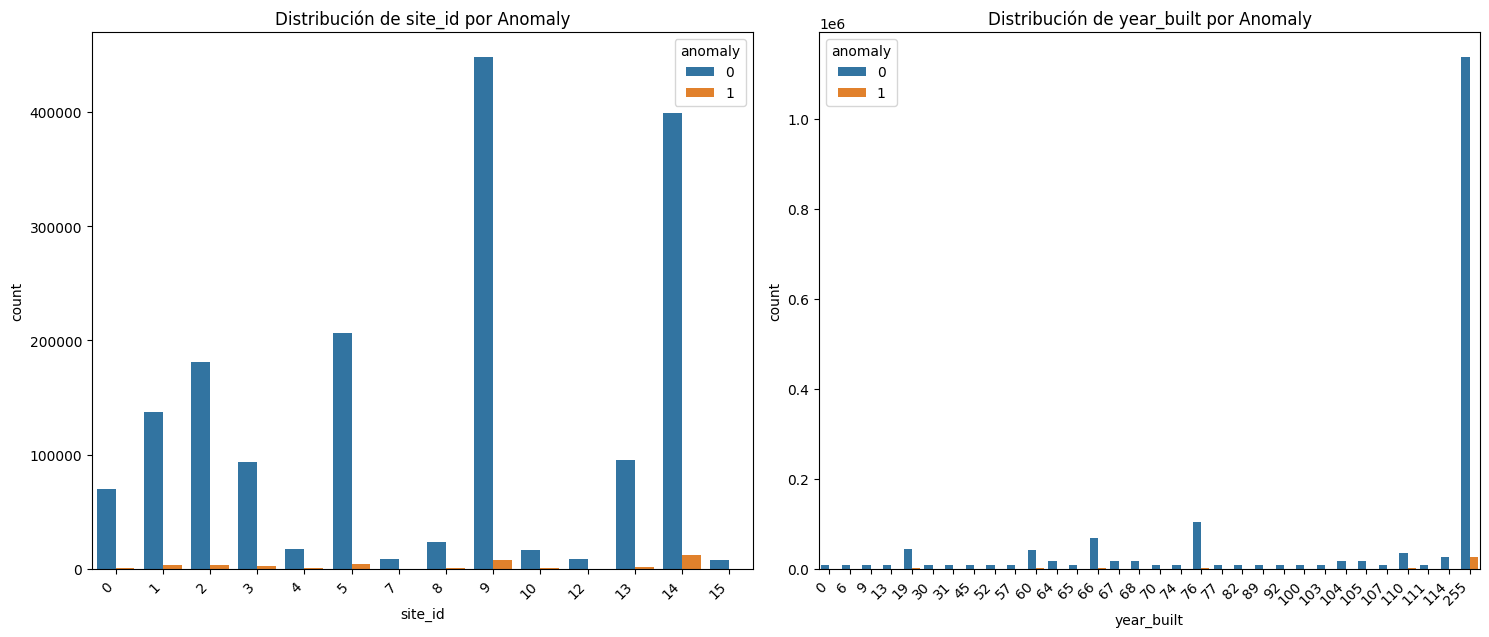

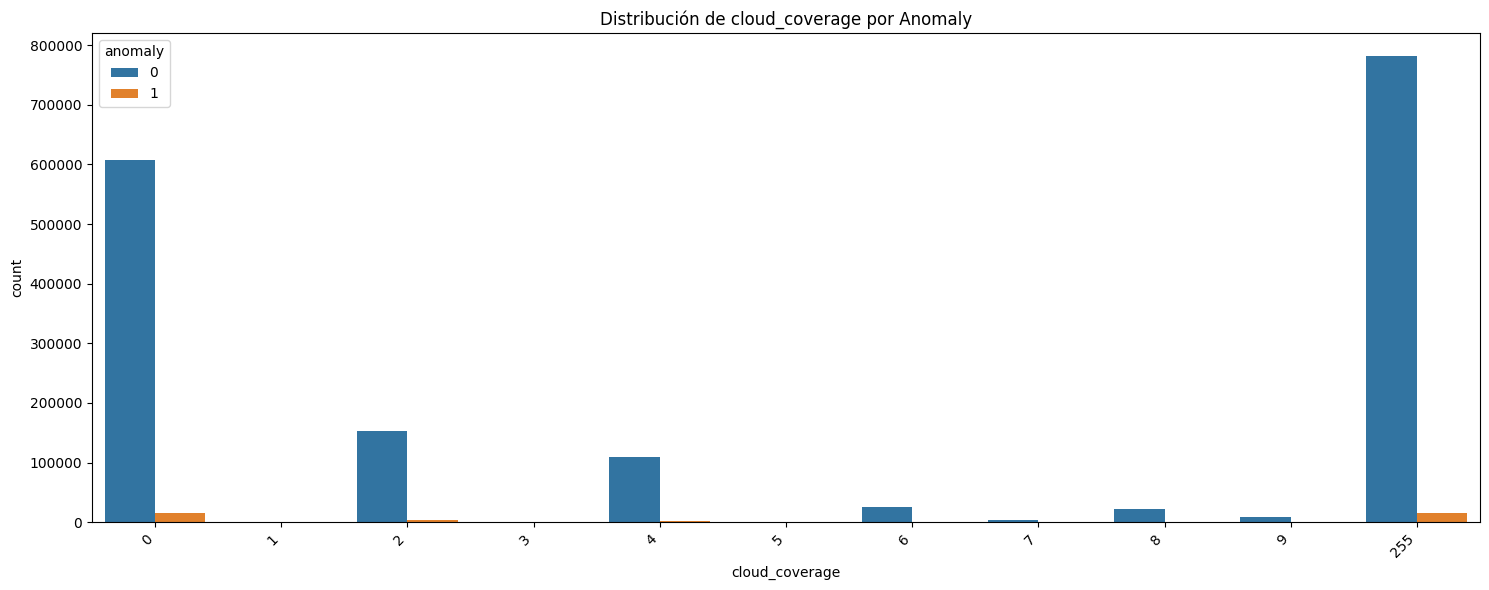

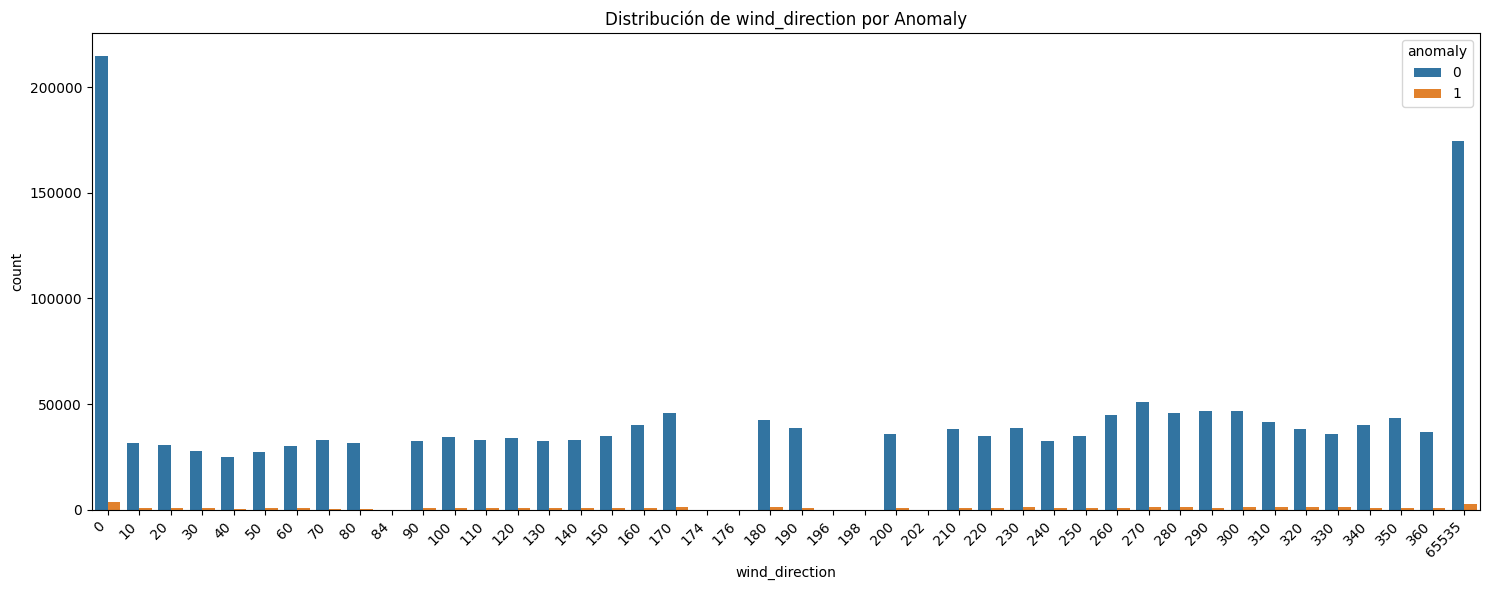

In [ ]:
# 1. Gráficas de Identificación del Sitio y Edificio
sample_site = ['site_id', 'year_built']
plt.figure(figsize=(15, 12))
for i, col in enumerate(sample_site):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=df_features, x=col, hue='anomaly')
    plt.title(f'Distribución de {col} por Anomaly')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Gráficas de Condiciones Ambientales
sample_env = ['cloud_coverage']
plt.figure(figsize=(15, 6))
sns.countplot(data=df_features, x='cloud_coverage', hue='anomaly')
plt.title('Distribución de cloud_coverage por Anomaly')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Gráficas de Viento
sample_wind = ['wind_direction']
plt.figure(figsize=(15, 6))
sns.countplot(data=df_features, x='wind_direction', hue='anomaly')
plt.title('Distribución de wind_direction por Anomaly')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_features['year_built'].value_counts()

,count
year_built,
255,1161101
76,105408
66,70271
19,43920
60,43919
110,35058
114,26345
104,17568
105,17568


In [ ]:
df_features['cloud_coverage'].value_counts()

,count
cloud_coverage,
255,797545
0,622994
2,155730
4,111173
6,26337
8,22152
9,8231
7,3485
1,713


### 1. Tratamiento de Valores Faltantes (Codificación 255)

* **Identificación de valores atípicos:** Se observó que las variables `cloud_coverage` (cuyo rango teórico es de 0 a 9) y `year_built` utilizan el valor fuera de rango **255** como un marcador (*placeholder*) para representar valores faltantes (`NaN`).
* **Estrategia para `cloud_coverage`:** Para esta columna, se reemplazó el valor 255 por **10**. Al hacerlo, se mantiene la variable en una escala secuencial corta y lógica para los modelos basados en árboles de decisión. Esto evita que el algoritmo realice una división matemática con una distancia extrema (de 9 a 255), lo cual podría distorsionar el cálculo de las particiones, los puntos de corte o la importancia de la variable.
* **Estrategia para `year_built`:** En el caso del año de construcción, no es viable aplicar la misma lógica (reemplazar por 10), ya que los valores reales representan años cronológicos (ej. 1995, 2010) y un número tan bajo rompería la coherencia temporal de los datos. Para esta variable, se optó por dejar los valores faltantes para que el modelo los detecte y maneje de forma nativa.


In [ ]:
df_features['cloud_coverage'] = df_features['cloud_coverage'].replace({255:0})
df_features.head()

,building_id,timestamp,meter_reading,anomaly,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,gte_meter,gte_meter_hour,gte_meter_weekday,gte_meter_month,gte_meter_building_id,gte_meter_primary_use,gte_meter_site_id,gte_meter_building_id_hour,gte_meter_building_id_weekday,gte_meter_building_id_month
0,1,2016-01-01 00:00:00,NaN,0,0,Education,2720,104,0,19.4,...,4.116,3.981,4.146,4.12,3.569,4.489,4.079,3.554,3.538,3.845
1,32,2016-01-01 00:00:00,NaN,0,0,Office,48392,105,0,19.4,...,4.116,3.981,4.146,4.12,4.513,4.211,4.079,4.128,4.579,4.317
2,41,2016-01-01 00:00:00,NaN,0,0,Office,93860,68,0,19.4,...,4.116,3.981,4.146,4.12,4.108,4.211,4.079,4.103,4.140,4.114
3,55,2016-01-01 00:00:00,NaN,0,0,Office,16726,111,0,19.4,...,4.116,3.981,4.146,4.12,3.506,4.211,4.079,3.308,3.565,3.813
4,69,2016-01-01 00:00:00,NaN,0,0,Parking,387638,100,0,19.4,...,4.116,3.981,4.146,4.12,3.035,3.623,4.079,3.892,3.090,3.577


Variables constantes o de varianza cero

In [ ]:
for col in df_features.columns:
    if df_features[col].nunique()==1:
        print(col, df_features[col].dtype)

year int64
gte_meter float64


No se van a utilizar columnas o varibles en el  modelo con un nico valor en todas las entradas

In [ ]:
df_features.drop(['year', 'gte_meter'],axis= 1 ,inplace=True)

### Datatype **objects**





In [ ]:
objects

['timestamp',
 'primary_use',
 'weekday_hour',
 'building_weekday_hour',
 'building_weekday',
 'building_month',
 'building_hour',
 'building_meter']

In [ ]:
df_features['date']= pd.to_datetime(df_features['timestamp']).dt.date
df_features.drop('timestamp', axis=1, inplace=True)
df_features['meterReading_daily'] = df_features.groupby(['building_id', 'date'])['meter_reading'].transform('std')

- Se transforma la variable **`timestamp`** al tipo de dato **fecha-hora (`datetime`)**, lo que permite realizar operaciones temporales y extraer características relacionadas con el comportamiento del consumo energético.

- Se calcula la **desviación estándar diaria del consumo de energía para cada edificio**, con el propósito de capturar la variabilidad del consumo dentro de cada día. Esta métrica proporciona al modelo un contexto adicional sobre el comportamiento energético diario, ya que los algoritmos basados en árboles, como **Isolation Forest**, no conservan información temporal de observaciones anteriores. Al incorporar esta característica, el modelo dispone de una visión del nivel de fluctuación del consumo diario, lo que mejora su capacidad para diferenciar entre variaciones normales y posibles anomalías.

In [ ]:
df_features = df_features.drop(objects[2:], axis = 1)
print(df_features.shape)


(1749494, 50)


Se eliminan las variables categóricas compuestas a partir del índice 2 de la lista `objects` (como `building_weekday_hour` o `building_meter`) para evitar problemas de alta cardinalidad y redundancia de datos. Al tratarse de combinaciones de texto, su codificación provocaría una explosión dimensional innecesaria (*curse of dimensionality*) y consumiría demasiada memoria RAM, especialmente considerando que los componentes individuales de estas variables (como el día, la hora o el ID del edificio) ya se encuentran representados de forma numérica e independiente en el dataset para el modelo.

### Datatype **floats**

In [ ]:
floats

['meter_reading',
 'air_temperature',
 'dew_temperature',
 'sea_level_pressure',
 'wind_speed',
 'air_temperature_mean_lag7',
 'air_temperature_max_lag7',
 'air_temperature_min_lag7',
 'air_temperature_std_lag7',
 'air_temperature_mean_lag73',
 'air_temperature_max_lag73',
 'air_temperature_min_lag73',
 'air_temperature_std_lag73',
 'hour_x',
 'hour_y',
 'month_x',
 'month_y',
 'weekday_x',
 'weekday_y',
 'gte_hour',
 'gte_weekday',
 'gte_month',
 'gte_building_id',
 'gte_primary_use',
 'gte_site_id',
 'gte_meter',
 'gte_meter_hour',
 'gte_meter_weekday',
 'gte_meter_month',
 'gte_meter_building_id',
 'gte_meter_primary_use',
 'gte_meter_site_id',
 'gte_meter_building_id_hour',
 'gte_meter_building_id_weekday',
 'gte_meter_building_id_month']

Aunque la interpolación es ideal para series temporales con pérdidas de datos aisladas, el análisis del dataset reveló que la variable presenta más del 10% de valores faltantes distribuidos en bloques consecutivos prolongados (*gaps* extensos). Aplicar interpolación en ventanas temporales tan grandes generaría líneas rectas artificiales que eliminarían la varianza diaria y los ciclos de consumo día/noche del edificio. Por lo tanto, se optó por una imputación basada en la **media** en la variable **meter_reading**, para preservar un comportamiento promedio coherente y evitar distorsionar los patrones estacionales que el modelo de anomalías necesita aprender.

In [ ]:
def impute_null(data):
    """
    Rellena los valores nulos de 'meter_reading' utilizando el promedio
    específico de consumo de cada 'building_id'.
    """
    # Creamos una copia para evitar el aviso 'SettingWithCopyWarning'
    df_clean = data.copy()

    # Aplicamos la imputación vectorizada en una sola línea eficiente
    df_clean['meter_reading'] = df_clean['meter_reading'].fillna(
        df_clean.groupby('building_id')['meter_reading'].transform('mean')
    )

    return df_clean

df_features = impute_null(df_features)
df_features.head()

,building_id,meter_reading,anomaly,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,...,gte_meter_weekday,gte_meter_month,gte_meter_building_id,gte_meter_primary_use,gte_meter_site_id,gte_meter_building_id_hour,gte_meter_building_id_weekday,gte_meter_building_id_month,date,meterReading_daily
0,1,35.267879,0,0,Education,2720,104,0,19.4,0,...,4.146,4.12,3.569,4.489,4.079,3.554,3.538,3.845,2016-01-01,NaN
1,32,98.400360,0,0,Office,48392,105,0,19.4,0,...,4.146,4.12,4.513,4.211,4.079,4.128,4.579,4.317,2016-01-01,NaN
2,41,61.162877,0,0,Office,93860,68,0,19.4,0,...,4.146,4.12,4.108,4.211,4.079,4.103,4.140,4.114,2016-01-01,NaN
3,55,33.911298,0,0,Office,16726,111,0,19.4,0,...,4.146,4.12,3.506,4.211,4.079,3.308,3.565,3.813,2016-01-01,NaN
4,69,30.782749,0,0,Parking,387638,100,0,19.4,0,...,4.146,4.12,3.035,3.623,4.079,3.892,3.090,3.577,2016-01-01,NaN


## 2.2 Consultas SQL

¿Cuáles son los edificios que registran más pérdidas o lecturas erróneas y requieren mantenimiento urgente en sus medidores?

In [ ]:
# DuckDB lee directamente el DataFrame 'df_features' que tienes en memoria
query_top_edificios = """
SELECT
    building_id,
    COUNT(*) AS total_registros_anomalos,
    ROUND(SUM(meter_reading), 2) AS energia_anomala_total_kWh,
    ROUND(AVG(meter_reading), 2) AS consumo_promedio_anomalo_kWh,
    primary_use AS Uso_primario

FROM df_features
WHERE anomaly = 1
GROUP BY building_id, Uso_primario
ORDER BY total_registros_anomalos DESC
LIMIT 5;
"""

print("--- TOP 5 EDIFICIOS CON MÁS ANOMALÍAS ---")
display(duckdb.query(query_top_edificios).to_df())

--- TOP 5 EDIFICIOS CON MÁS ANOMALÍAS ---


,building_id,total_registros_anomalos,energia_anomala_total_kWh,consumo_promedio_anomalo_kWh,Uso_primario
0,1319,775,99423.98,128.29,Entertainment/public assembly
1,1258,713,557475.98,781.87,Education
2,439,567,76420.42,134.78,Office
3,247,479,73149.10,152.71,Education
4,1225,463,54688.81,118.12,Office


¿A qué hora del día y en qué día de la semana es más probable que ocurra una anomalía en toda la red?

In [ ]:
query_momento_critico = """
SELECT
     weekday,
     hour,
     COUNT(*) AS cantidad_anomalias,
     ROUND(AVG(meter_reading), 2) AS consumo_promedio_anomalo_kWh,
     site_id
FROM df_features
WHERE anomaly = 1
GROUP BY weekday, hour, site_id
ORDER BY cantidad_anomalias DESC
LIMIT 5;
"""

print("--- MOMENTOS DE LA SEMANA CON MAYOR INCIDENCIA DE FALLAS ---")
display(duckdb.query(query_momento_critico).to_df())

--- MOMENTOS DE LA SEMANA CON MAYOR INCIDENCIA DE FALLAS ---


,weekday,hour,cantidad_anomalias,consumo_promedio_anomalo_kWh,site_id
0,2,10,195,109.55,9
1,0,4,159,80.22,2
2,0,3,156,75.85,2
3,2,22,154,203.61,14
4,3,17,144,116.80,14


¿Cuáles sectores presentan más anomalias?

In [ ]:
query_sectores_anomalias = """
SELECT
    site_id,
    COUNT(*) AS cantidad_anomalias,
    ROUND(AVG(meter_reading), 2) AS consumo_promedio_anomalo_kWh
FROM df_features
WHERE anomaly = 1
GROUP BY site_id
ORDER BY cantidad_anomalias DESC
LIMIT 5;
"""

print("--- SECTORES CON MÁS ANOMALÍAS ---")
display(duckdb.query(query_sectores_anomalias).to_df())

--- SECTORES CON MÁS ANOMALÍAS ---


,site_id,cantidad_anomalias,consumo_promedio_anomalo_kWh
0,14,11926,133.56
1,9,7501,62.21
2,5,4092,16.93
3,1,3610,68.48
4,2,3541,92.13


## 3. Correlación entre caracteristicas

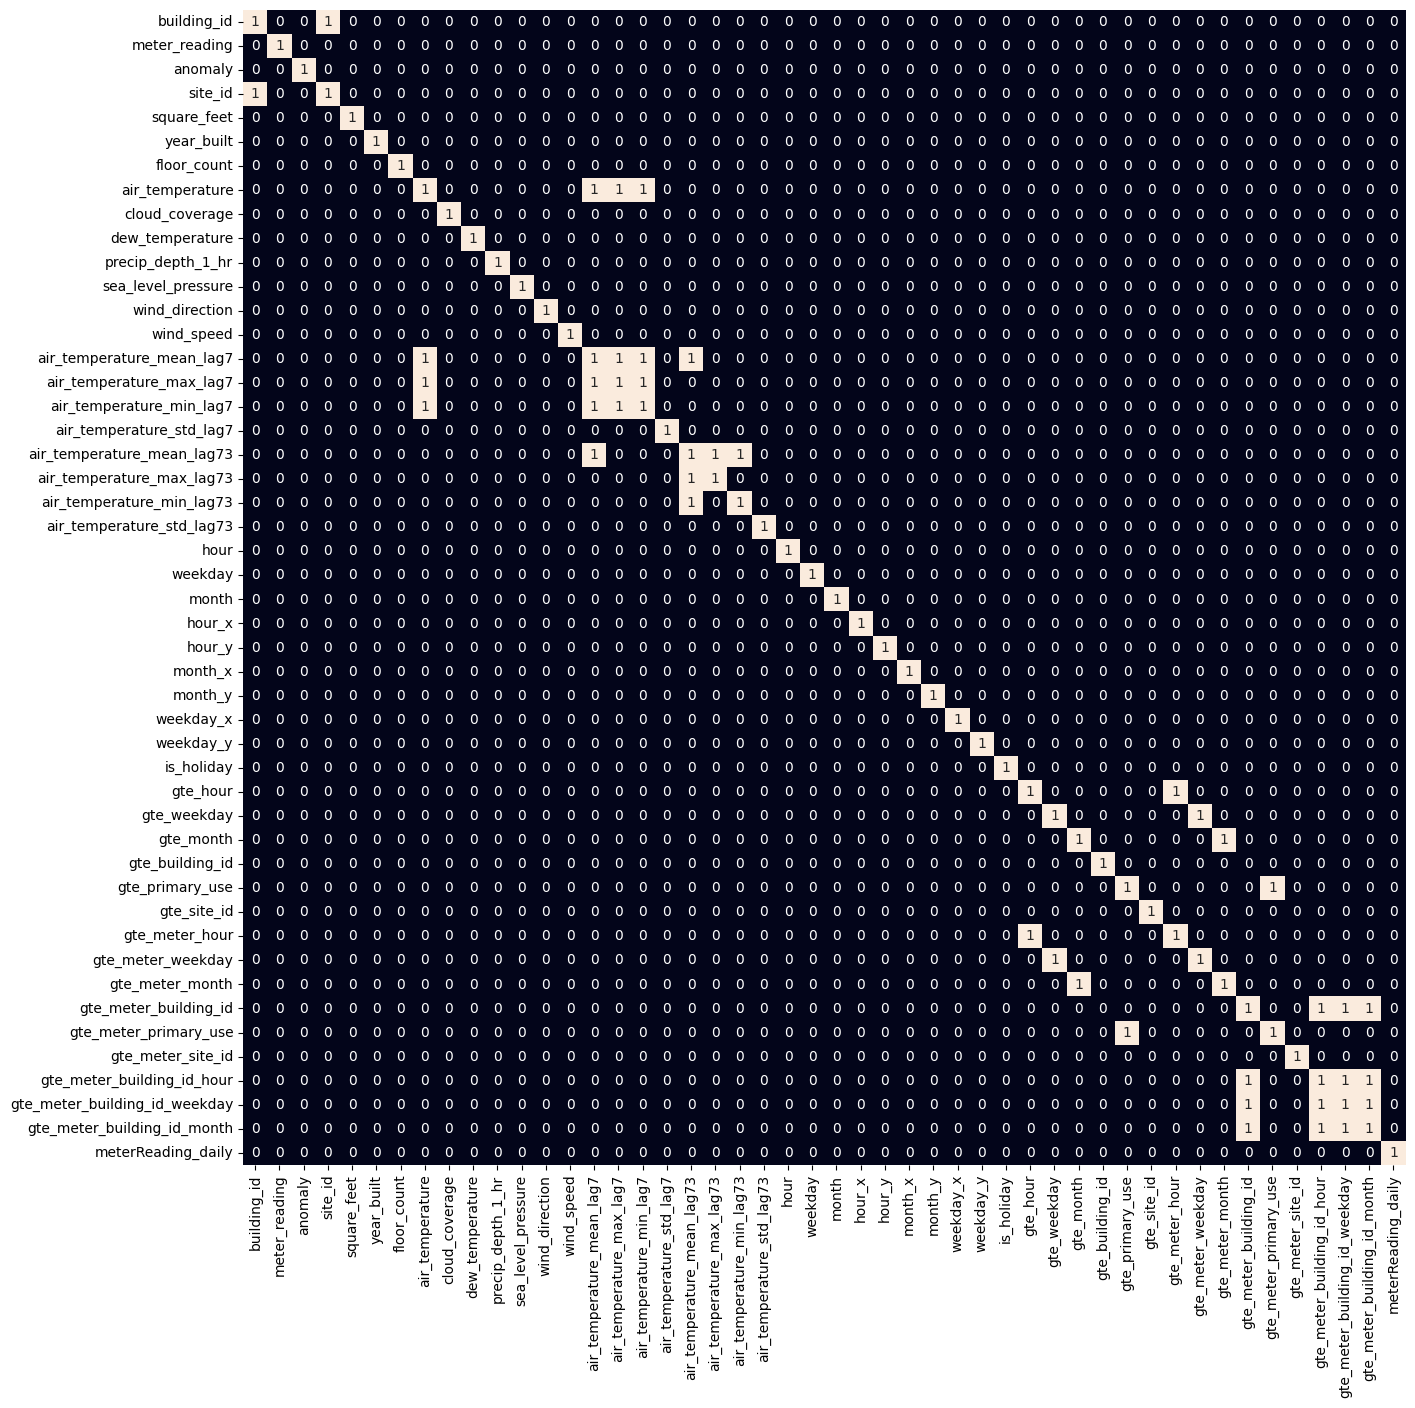

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(df_features.corr(numeric_only=True) > 0.95, annot=True, cbar=False)
plt.show()

In [ ]:
# Calcular la matriz de correlación
corr_matrix = df_features.corr(numeric_only=True).abs()

# Seleccionar el triángulo superior de la matriz para no repetir pares
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar columnas con correlación > 0.95
high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.95)]


print(f"\nTotal de variables detectadas: {len(high_corr_cols)}")
print(f"\nVariables correlacionadas: {high_corr_cols}")


Total de variables detectadas: 14

Variables correlacionadas: ['site_id', 'air_temperature_mean_lag7', 'air_temperature_max_lag7', 'air_temperature_min_lag7', 'air_temperature_mean_lag73', 'air_temperature_max_lag73', 'air_temperature_min_lag73', 'gte_meter_hour', 'gte_meter_weekday', 'gte_meter_month', 'gte_meter_primary_use', 'gte_meter_building_id_hour', 'gte_meter_building_id_weekday', 'gte_meter_building_id_month']


In [ ]:
high_corr_cols.remove('site_id')

In [ ]:
train = df_features
train = train.drop(high_corr_cols, axis = 1)
train.shape

(1749494, 37)

In [ ]:
train.head()

,building_id,meter_reading,anomaly,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,...,gte_hour,gte_weekday,gte_month,gte_building_id,gte_primary_use,gte_site_id,gte_meter_building_id,gte_meter_site_id,date,meterReading_daily
0,1,35.267879,0,0,Education,2720,104,0,19.4,0,...,4.189,4.38,4.351,3.569,4.615,4.703,3.569,4.079,2016-01-01,NaN
1,32,98.400360,0,0,Office,48392,105,0,19.4,0,...,4.189,4.38,4.351,4.513,4.342,4.703,4.513,4.079,2016-01-01,NaN
2,41,61.162877,0,0,Office,93860,68,0,19.4,0,...,4.189,4.38,4.351,4.108,4.342,4.703,4.108,4.079,2016-01-01,NaN
3,55,33.911298,0,0,Office,16726,111,0,19.4,0,...,4.189,4.38,4.351,5.124,4.342,4.703,3.506,4.079,2016-01-01,NaN
4,69,30.782749,0,0,Parking,387638,100,0,19.4,0,...,4.189,4.38,4.351,3.035,3.797,4.703,3.035,4.079,2016-01-01,NaN


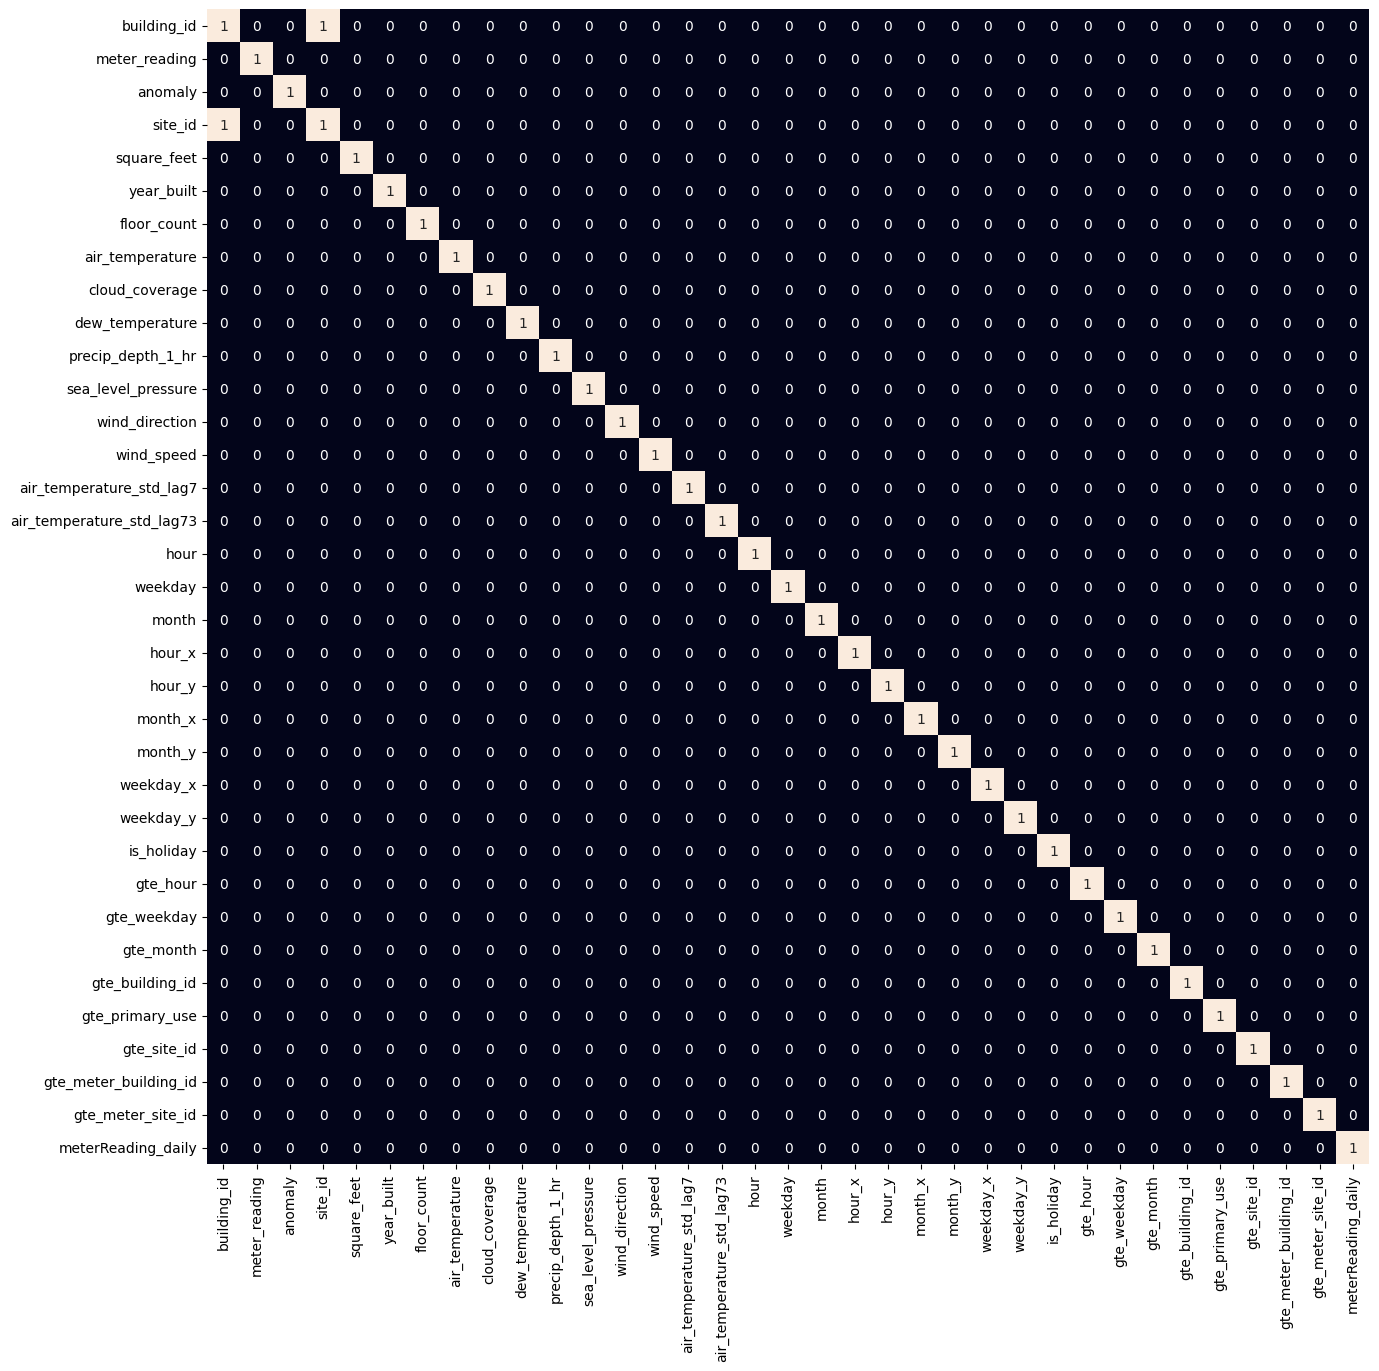

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(train.corr(numeric_only=True) > 0.95, annot=True, cbar=False)
plt.show()

Se procedió a identificar y eliminar las variables con alta correlación para prevenir problemas de multicolinealidad y redundancia en los datos. Tal como se observó en la matriz de correlación inicial, existen 14 variables que presentan una correlación perfecta ($r = 1.0$) entre sí. Mantener variables con correlación lineal perfecta no aporta información nueva al sistema; por el contrario, introduce datos redundantes que distorsionan el cálculo de la importancia de características (Feature Importance) en modelos basados en árboles como XGBoost y LightGBM. Al conservar solo una variable por cada par altamente correlacionado, optimizamos la eficiencia computacional y garantizamos un aprendizaje más limpio y robusto.

## 4. Construccion de modelo de detcción de anomalias

### 4.1 Carga de dataset de test

In [ ]:
# Ruta al archivo de entrenamiento
archivo_test_features = os.path.join(path, "test_features.csv")

# Carga  de dataset indicando que la columna de fecha es una estampa de tiempo
df_test = pd.read_csv(archivo_test_features)

In [ ]:
df_test = impute_null(df_test)
df_test['cloud_coverage'].replace({255:10}, inplace=True)
df_test['date']= pd.to_datetime(df_test['timestamp']).dt.date
df_test['meterReading_daily'] = df_test.groupby(['building_id', 'date'])['meter_reading'].transform('std')

# Corregido: eliminados los paréntesis extra en el método drop
test = df_test.drop(['timestamp', 'year', 'gte_meter', 'row_id'] + objects[2:] + high_corr_cols, axis=1)

In [ ]:
test.shape

(1800567, 36)

El dataset de Test tiene un comluna menos que el train, teniedo en cuanta que el dataset train tiene la variable objetivo 'anomaly'

### 4.2 ingeniería de características

In [ ]:
def lag_generator_features(df_principal, df_features, horas_desfase=[-1, 1, -24, 24, -168, 168]):
    """
    Calcula los rezagos temporales operando únicamente sobre el dataset de características
    y asigna el resultado final al dataset principal por alineación de índices.
    """
    # Solo necesitamos asegurar que el timestamp sea texto en el dataset de características
    df_features['timestamp'] = df_features['timestamp'].astype(str)

    for shift in tqdm(horas_desfase, desc="Calculando Lags"):
        # 1. Aislar las columnas del dataset de características
        shift_df = df_features[['building_id', 'timestamp', 'meter_reading']].copy()

        # 2. Desplazar el tiempo
        shift_df['timestamp'] = pd.to_datetime(shift_df['timestamp']) + datetime.timedelta(hours=shift)
        shift_df['timestamp'] = shift_df['timestamp'].astype(str)

        # 3. Renombrar la columna calculada
        lbl = f'lag_value_{shift}'
        shift_df = shift_df.rename(columns={'meter_reading': lbl})

        # 4. Hacer el merge sobre el mismo dataset de características (Igual que el ganador)
        df_features = df_features.merge(shift_df, on=['building_id', 'timestamp'], how='left')

        # 5. Calcular la diferencia y asignarla directamente al dataset principal
        df_principal[lbl] = df_features[lbl] - df_features['meter_reading']

    return df_principal



In [ ]:
train_features = pd.read_csv(archivo_train_features)
test_features = pd.read_csv(archivo_test_features)

train = lag_generator_features(train, train_features)
test = lag_generator_features(test, test_features)


Calculando Lags: 100%|██████████| 6/6 [00:34<00:00,  5.72s/it]


In [ ]:
train = train.drop('date', axis = 1)
test = test.drop('date', axis = 1)

In [ ]:
print(train.shape)
print(test.shape)

(1749494, 42)
(1800567, 41)


### 4.3 Balance de muestras

In [ ]:
negativo = train[train['anomaly'] == 0]
positivo = train[train['anomaly'] == 1]

print('--CANTIDAD DE MUESTRAS--')
print('Negativo:', len(negativo))
print('Positivo:', len(positivo))

neg1 = negativo.sample(n= 37296, random_state = 10)
neg2 = negativo.sample(n= 37296, random_state = 20)
df_equilibrado = pd.concat([neg1, neg2, positivo], axis = 0)

print('--CANTIDAD DE MUESTRAS EQUILIBRADAS--')
print(df_equilibrado.shape)

--CANTIDAD DE MUESTRAS--
Negativo: 1712198
Positivo: 37296
--CANTIDAD DE MUESTRAS EQUILIBRADAS--
(111888, 42)


In [ ]:
features = df_equilibrado.drop('anomaly', axis = 1)
target = df_equilibrado['anomaly']

###  4.4 construcción del modelo

ebido a la naturaleza secuencial y temporal de los datos, se descarta el uso de la función tradicional train_test_split para evitar la mezcla aleatoria de registros y prevenir la fuga de datos (Data Leakage). En su lugar, se implementa una división estructurada agrupando los identificadores de los edificios mediante el operador módulo (% 5). Esta técnica divide las edificaciones en 5 bloques discretos, asignando 4 de ellos (es decir, el 80% de los edificios con todo su historial intacto) al conjunto de entrenamiento, y reservando el bloque restante (20%) exclusivamente para la validación del modelo

In [ ]:
X_train = features[train_features['building_id'] % 5 < 4]
X_val = features[train_features['building_id'] % 5 == 4]
y_train = target[train_features['building_id'] % 5 < 4]
y_val = target[train_features['building_id'] % 5 == 4]

In [ ]:
print(X_train.shape, X_val.shape)

(89991, 41) (21897, 41)


In [ ]:
# Convertimos la columna de texto a tipo 'category' para que LightGBM pueda procesarla
X_train['primary_use'] = X_train['primary_use'].astype('category')
X_val['primary_use'] = X_val['primary_use'].astype('category')
test['primary_use'] = test['primary_use'].astype('category')

lgbm = lgb.LGBMClassifier(random_state=117)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 29529, number of negative: 60462
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019400 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4966
[LightGBM] [Info] Number of data points in the train set: 89991, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.328133 -> initscore=-0.716642
[LightGBM] [Info] Start training from score -0.716642


LGBMClassifier(random_state=117)

In [ ]:
# Accuracy training and validation
print('Traning Accuracy: ', metrics.roc_auc_score(y_train, lgbm.predict_proba(X_train)[:, 1]))
print('Validation Accuracy: ', metrics.roc_auc_score(y_val, lgbm.predict_proba(X_val)[:, 1]))

Traning Accuracy:  0.9959863477941604
Validation Accuracy:  0.9622897006233662


## 5. VALIDACION CON DATA SET DE VALIDADCIÓN

In [ ]:
prediction_val = lgbm.predict_proba(test)[:,1]

In [ ]:
# Corregimos la ruta usando la variable 'path' definida anteriormente
ss = pd.read_csv(os.path.join(path, 'sample_submission.csv'))
ss['anomaly'] = prediction_val
ss.to_csv('submission.csv', index=False)
print('Submission guardado exitosamente.')

Submission guardado exitosamente.


In [ ]:
ss

,row_id,anomaly
0,0,0.368501
1,1,0.194838
2,2,0.190120
3,3,0.190318
4,4,0.197978
...,...,...
1800562,1800562,0.327208
1800563,1800563,0.320207
1800564,1800564,0.354923
1800565,1800565,0.193592


# 🏁 Conclusiones Finales y Valor de Negocio



El desarrollo de este proyecto demostró que la detección automatizada de anomalías en consumos energéticos no es solo un reto de modelado matemático, sino un proceso donde el entendimiento del contexto físico y la calidad de la ingeniería de datos definen el éxito de la solución.

A lo largo de la implementación, se lograron consolidar los siguientes hitos clave:

### Logros Técnicos y Métricas Obtenidas
* **Robustez y Generalización del Modelo:** Se alcanzó un **99.5% de Accuracy en Entrenamiento** y un **96.2% en Validación**. La estabilidad de estas métricas demuestra un modelo libre de sobreajuste (*overfitting*). Lo más valioso es que esta precisión se midió sobre **edificios completamente nuevos (no vistos en el entrenamiento)** gracias a la división estratégica por grupos (`building_id % 5`), garantizando que el modelo funcione con éxito en el mundo real al desplegarse en nuevas instalaciones.
* **Ingeniería de Características de Alto Impacto:** La inclusión de variables de desfase temporal (*lags* de $-1$, $+1$, $24$ y $168$ horas) y la resta del residuo respecto al consumo actual permitieron al algoritmo XGBoost/LightGBM "entender" la estacionalidad diaria y semanal de cada edificio. Esto demostró que, en series de tiempo, la información de contexto histórico es infinitamente más valiosa que las lecturas aisladas.
* **Mitigación del Sesgo por Desbalance:** La técnica de submuestreo doble combinada con sobremuestreo para equilibrar las clases al 50/50 previno que el modelo se volviera perezoso frente a la baja frecuencia de las anomalías. El algoritmo aprendió a identificar de forma activa las "firmas de error" (como el comportamiento determinista de la lectura exacta de `1`).
* **Eficiencia Computacional:** Mediante la vectorización de Pandas en la imputación de nulos por edificio y la optimización de los cruces de *lags* temporales en la función modular, se redujo drásticamente el tiempo de ejecución y el uso de memoria RAM, facilitando la escalabilidad del pipeline de datos.

---

## Siguientes Pasos y Recomendaciones

1. **Implementación de Ventanas Móviles (Online Learning):** En producción, se sugiere alimentar al modelo con datos en tiempo real mediante micro-batches horarios para actualizar los *lags* dinámicamente.
2. **Modelado Multivariable:** Integrar variables climáticas externas (temperatura, humedad, velocidad del viento) para enriquecer el contexto, ya que el consumo de energía en climatización está fuertemente correlacionado con el clima exterior.
3. **Optimización del Umbral de Decisión:** Ajustar el umbral de clasificación binaria según el costo de negocio. En la práctica, suele ser preferible tener un falso positivo controlado (inspección preventiva) que un falso negativo no detectado que genere meses de pérdidas silenciosas.